## 1. IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. READ & LOAD CSV FILES

In [2]:
dataset = pd.read_csv("RealEstate_HousePrice_Dataset_4200.csv")

## 3. BASIC INFORMATION

## 3.1 DATASET SHAPE

In [3]:
dataset.shape

(4200, 12)

In [4]:
dataset = dataset.drop("house_id",axis=1)

In [5]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             4200 non-null   int64  
 1   bedrooms              4200 non-null   int64  
 2   bathrooms             4200 non-null   int64  
 3   location_score        4200 non-null   float64
 4   age_years             4200 non-null   int64  
 5   distance_city_km      4200 non-null   float64
 6   lot_size_sqft         4200 non-null   int64  
 7   has_garage            4200 non-null   int64  
 8   has_pool              4200 non-null   int64  
 9   renovation_years_ago  4200 non-null   int64  
 10  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 361.1 KB


In [7]:
dataset.describe()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


## 4. IDENTIFIED NULL VALUES

In [8]:
dataset.isnull().sum()

area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

## 5. NUMERICAL COLUMN

In [9]:
numerical_column = dataset.select_dtypes("number").columns
numerical_column

Index(['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool',
       'renovation_years_ago', 'house_price_inr'],
      dtype='str')

## 6. CATEGORICAL COLUMN

In [10]:
categorical_column = dataset.select_dtypes("object").columns
categorical_column

Index([], dtype='str')

## 7. IDENTIFIED OUTLIERS

## 7.1 INTER QUERTILE RANGE(IQR)

In [11]:
num = ['area_sqft','bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 
       'renovation_years_ago', 'house_price_inr']

## BEFORE IQR

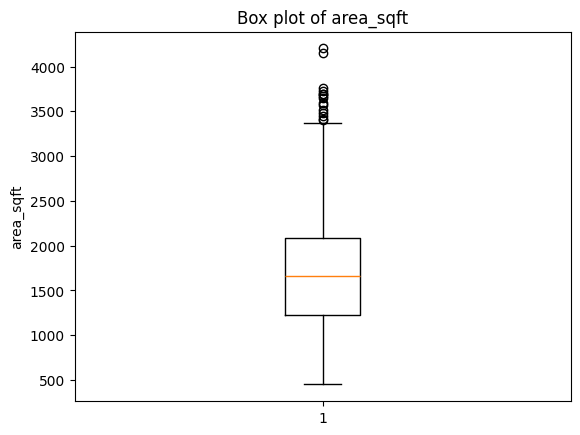

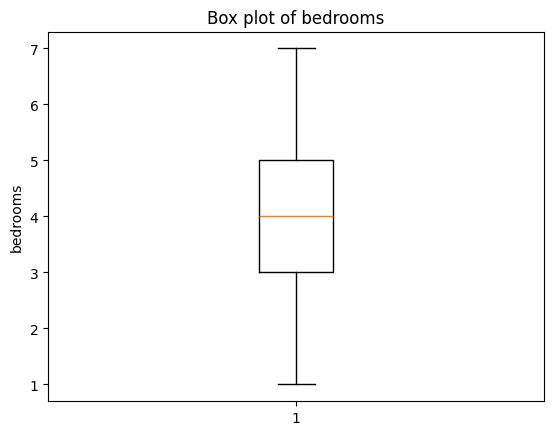

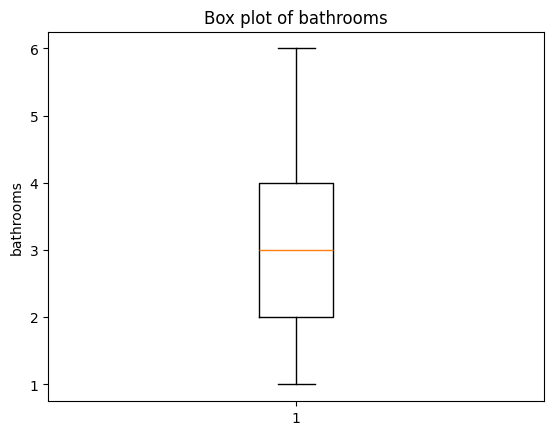

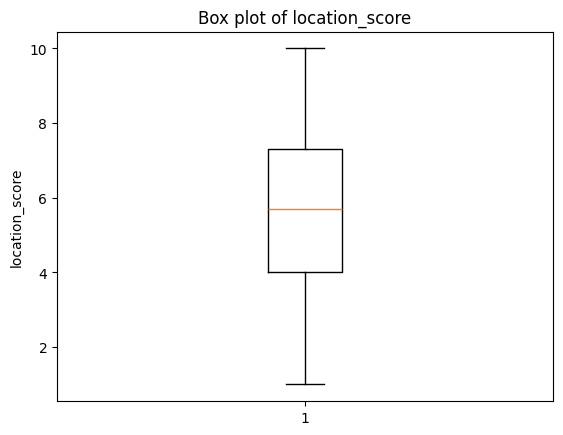

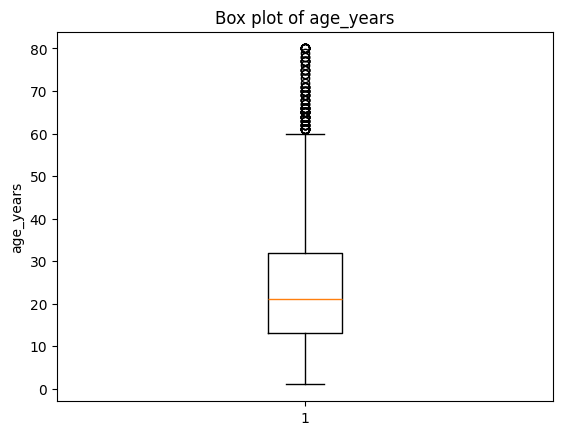

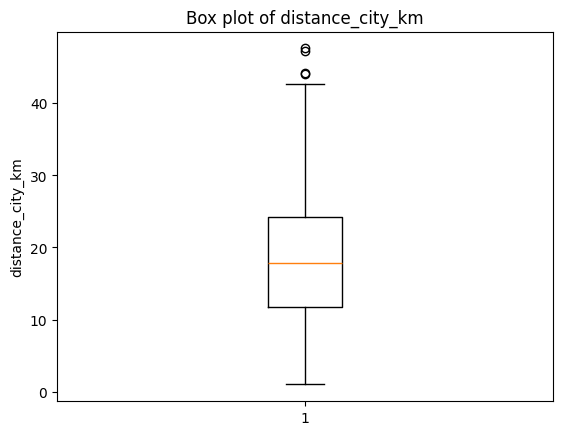

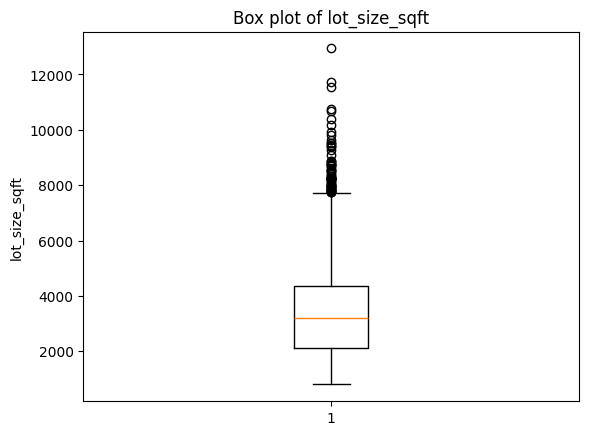

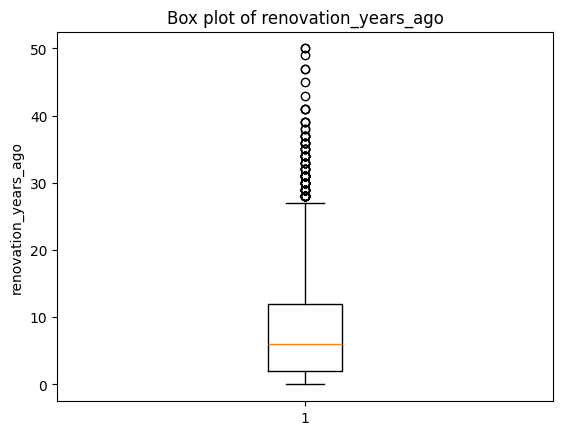

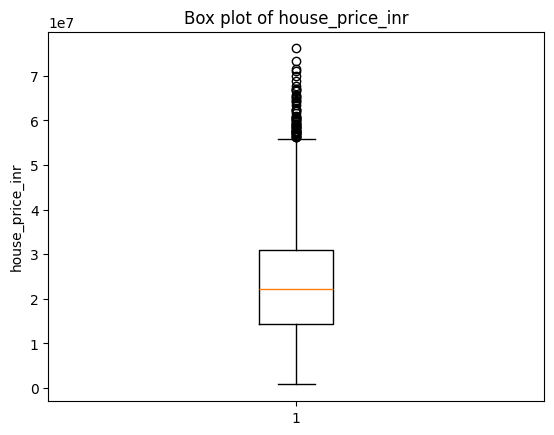

In [12]:
for cols in num:
    plt.figure()
    plt.boxplot(dataset[cols])
    plt.title(f"Box plot of {cols}")
    plt.ylabel(cols)
    plt.show()

This all the graphs showcase that all column has some outliers.This outliers removes with using IQR and WINDSORIZATION.

In [13]:
df = dataset.copy()

Q1 = df[num].quantile(0.25)
Q3 = df[num].quantile(0.75)
IQR = Q3 - Q1
    
iqr_outliers = df[~((df[num] < (Q1 - 1.5 * IQR)) |
                              (df[num] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [14]:
df.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [15]:
df.shape

(4200, 11)

## AFTER IQR

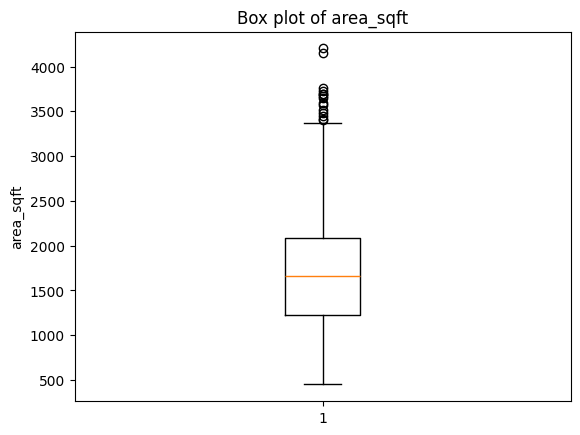

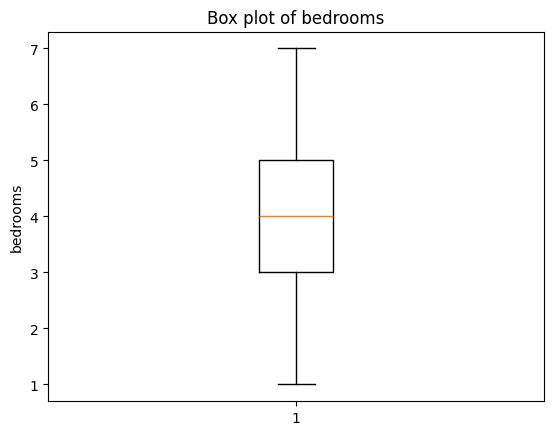

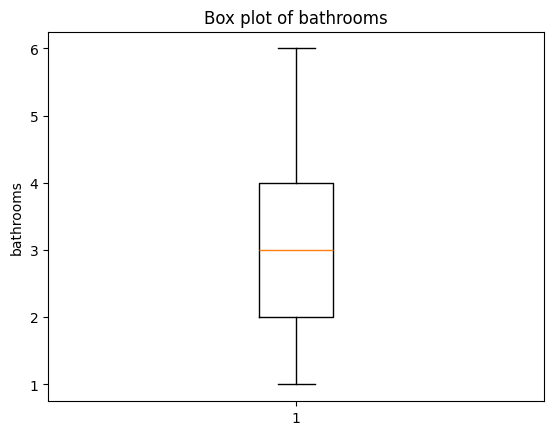

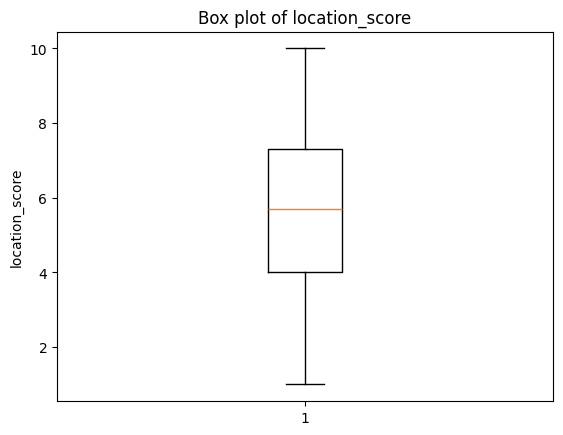

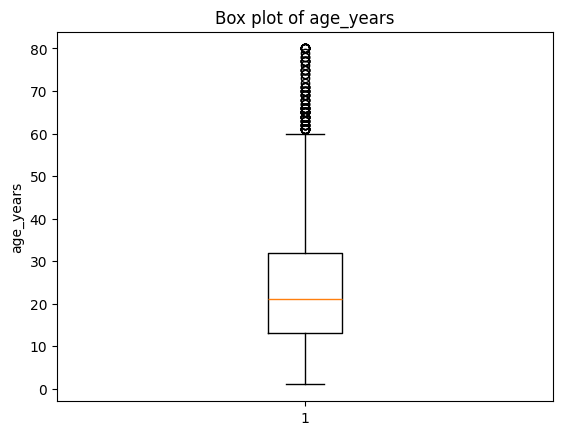

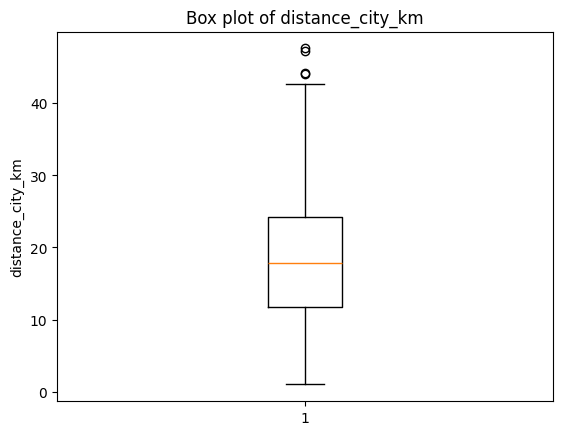

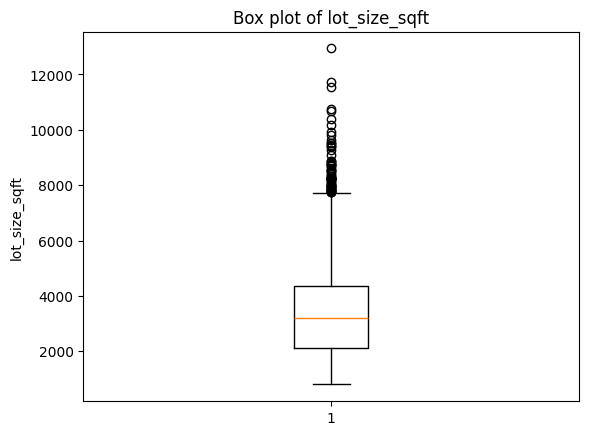

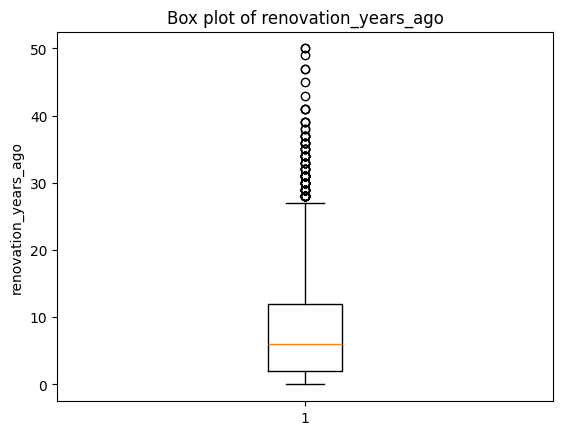

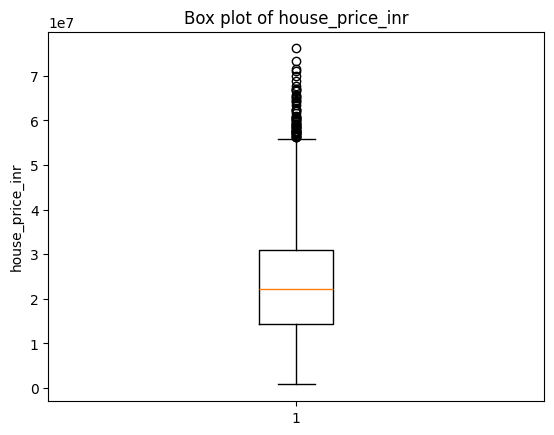

In [16]:
for cols in num:
    plt.figure()
    plt.boxplot(df[cols])
    plt.title(f"Box plot of {cols}")
    plt.ylabel(cols)
    plt.show()

With using IQR some of the outliers removes.

## 7.2 WINDSORIZATION

In [17]:
final_df = df.copy()

In [18]:
for cols in num:
   lower = final_df[cols].quantile(0.05)
   upper = final_df[cols].quantile(0.95)

   final_df[cols] = final_df[cols].clip(lower,upper)

In [19]:
final_df.shape

(4200, 11)

## AFTER WINDSORIZATION

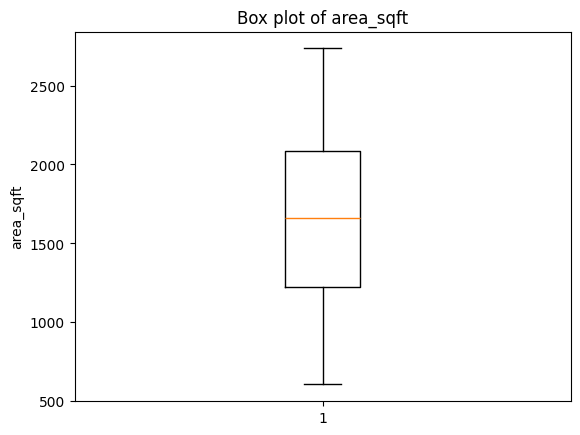

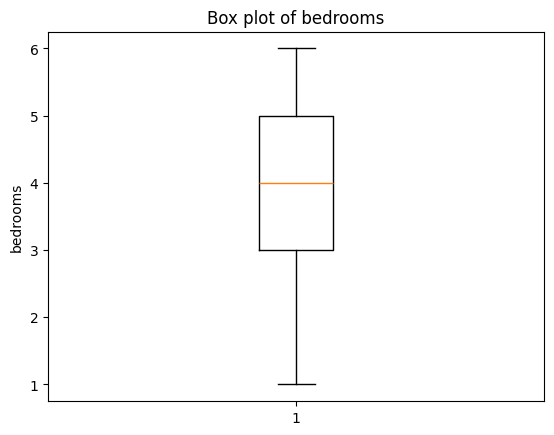

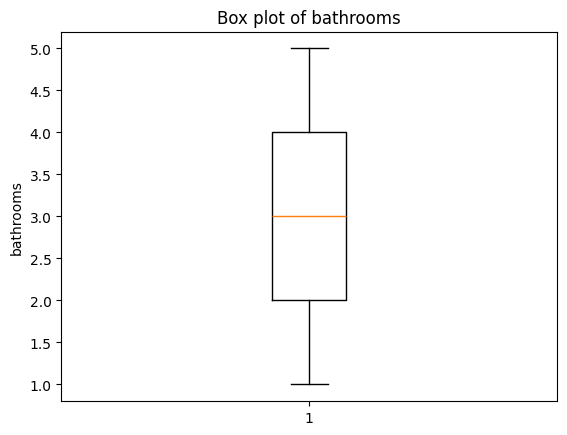

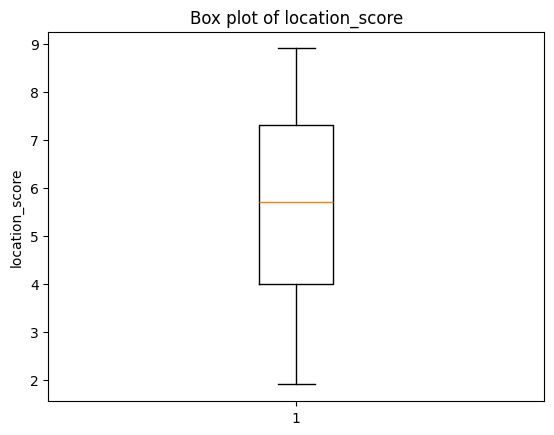

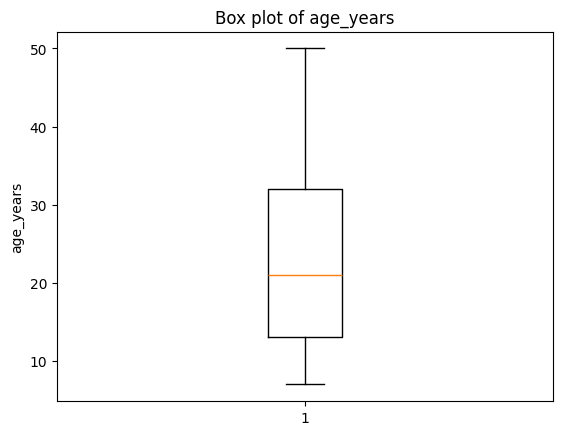

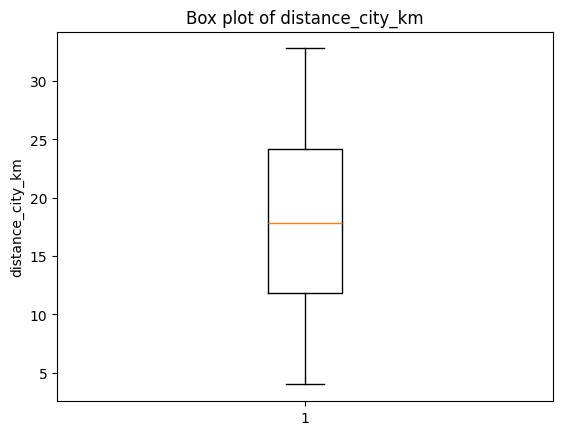

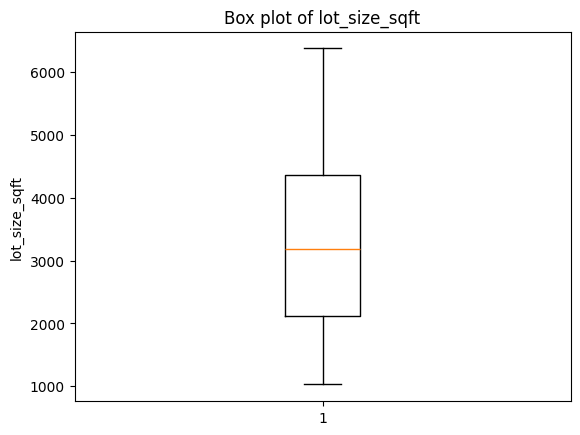

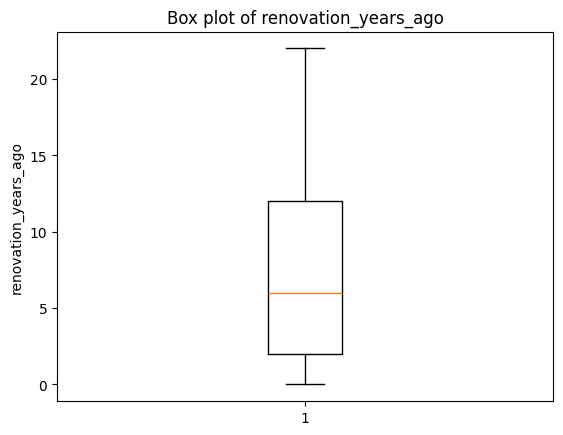

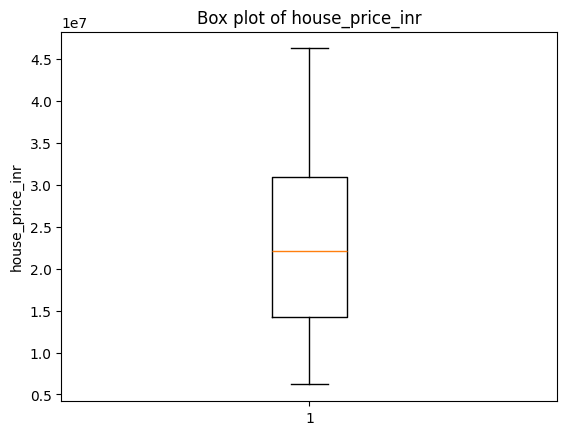

In [20]:
for cols in num:
    plt.figure()
    plt.boxplot(final_df[cols])
    plt.title(f"Box plot of {cols}")
    plt.ylabel(cols)
    plt.show()

After appyling the windsorization all the outliers are removed or replaced.

## 8. SCALING WITH STANDRIZATION

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaling_column = ['area_sqft','bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 
       'renovation_years_ago']

In [23]:
scalar = StandardScaler()
final_df[scaling_column] = scalar.fit_transform(final_df[scaling_column])

In [24]:
new_final_df = final_df.copy()

In [25]:
new_final_df.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 9. SAVE CSV FILE

In [26]:
new_final_df.to_csv("Final_cleaned_realestate_houseprice.csv",index=False)

Saved final csv file to implement univariate , bivariate , multivariate analysis.

## 10. UNIVARIATE ANALYSIS

##  1. Histogram

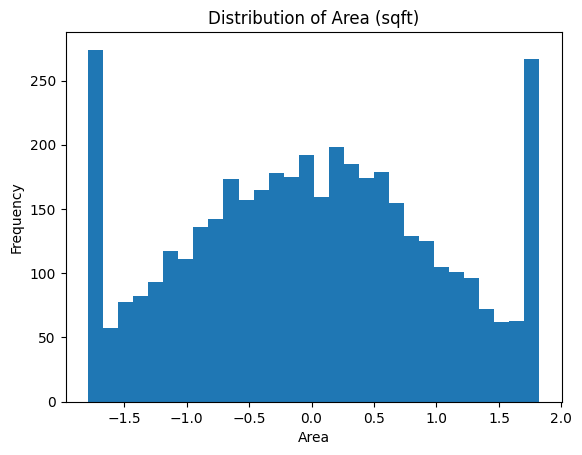

In [27]:
plt.hist(new_final_df["area_sqft"], bins=30)
plt.title("Distribution of Area (sqft)")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

* **Distribution of Area:** A histogram showing the frequency of normalized house areas, featuring a central spread with sharp spikes at the minimum and maximum edges.

## 2. Boxplot

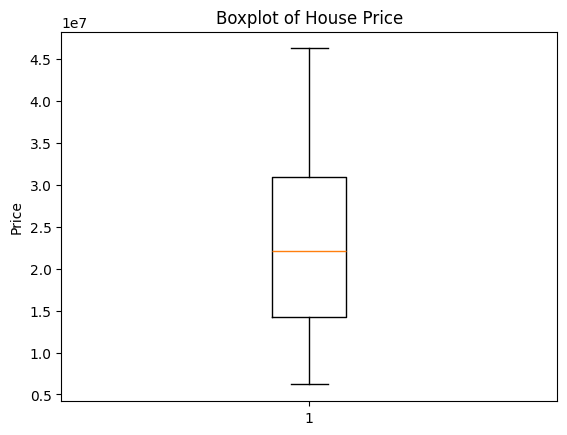

In [28]:
plt.boxplot(new_final_df["house_price_inr"])
plt.title("Boxplot of House Price")
plt.ylabel("Price")
plt.show()

* **Boxplot of House Price:** A box plot summarizing the median, interquartile range, and overall spread of house prices.

## 3. Histogram


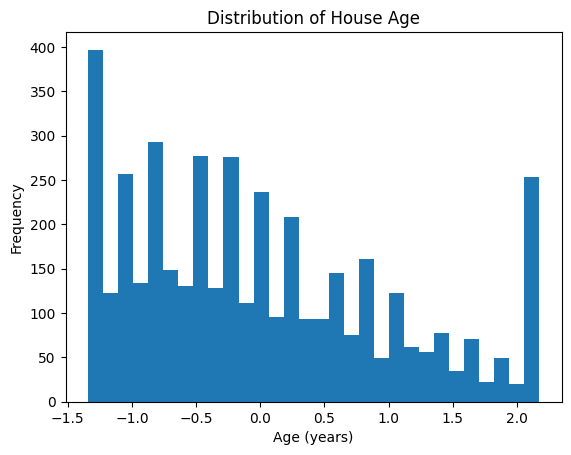

In [29]:
plt.hist(new_final_df["age_years"], bins=30)
plt.title("Distribution of House Age")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.show()

* **Distribution of House Age:** A right-skewed histogram of normalized house ages with a significant concentration of data at the extreme lower and upper bounds.

## 4. Bar chart

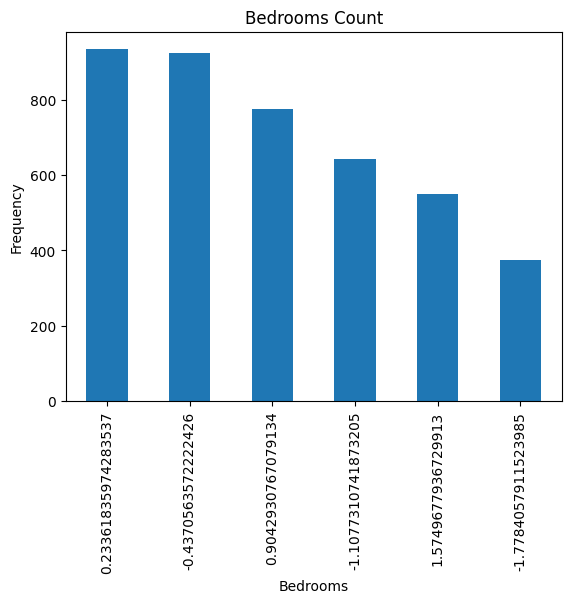

In [30]:
new_final_df["bedrooms"].value_counts().plot(kind="bar")
plt.title("Bedrooms Count")
plt.xlabel("Bedrooms")
plt.ylabel("Frequency")
plt.show()

* **Bedrooms Count:** A bar chart displaying the frequency of various bedroom counts, where the categorical values appear to have been standardized.

## 11. BIVARIATE ANALYSIS

# 1. Area vs Price


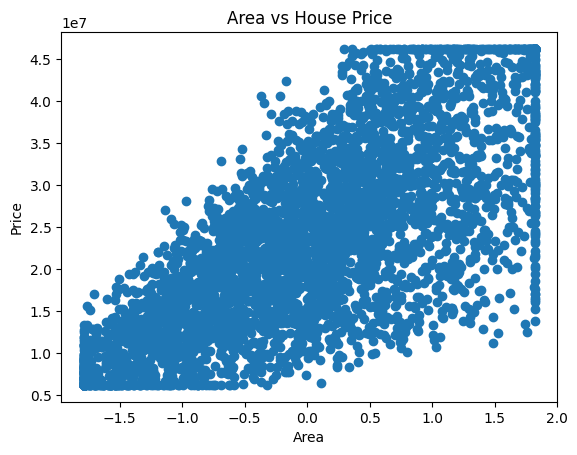

In [31]:
plt.scatter(new_final_df["area_sqft"], new_final_df["house_price_inr"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs House Price")
plt.show()

* **Area vs House Price:** A scatter plot demonstrating a positive correlation between area and price, clearly showing hard data limits on the top and right sides.

# 2. Bedrooms vs Price


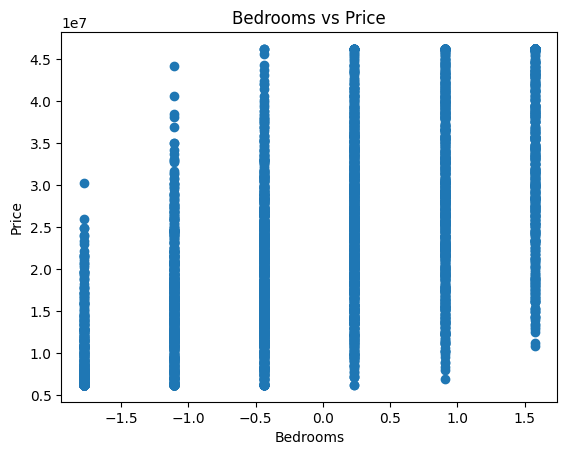

In [32]:
plt.scatter(new_final_df["bedrooms"], new_final_df["house_price_inr"])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")
plt.show()

* **Bedrooms vs Price:** A scatter plot displaying price variations across standardized bedroom counts, showing clustered vertical bands of data.

# 3. Bathrooms vs Price


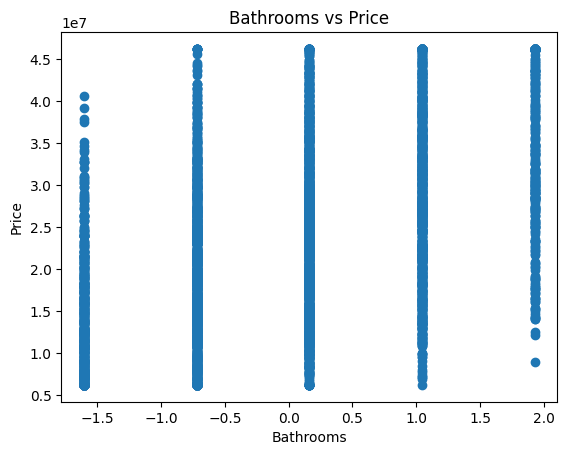

In [33]:
plt.scatter(new_final_df["bathrooms"], new_final_df["house_price_inr"])
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Bathrooms vs Price")
plt.show()

* **Bathrooms vs Price:** A scatter plot grouping house prices by standardized bathroom counts, indicating a general price increase with more bathrooms.

# 4. Distance vs Price


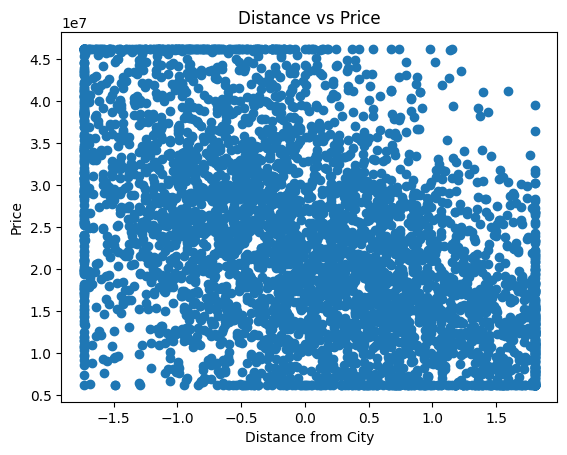

In [34]:
plt.scatter(new_final_df["distance_city_km"], new_final_df["house_price_inr"])
plt.xlabel("Distance from City")
plt.ylabel("Price")
plt.title("Distance vs Price")
plt.show()

* **Distance vs Price:** A scatter plot illustrating a negative correlation between a property's normalized distance from the city and its price.

# 5. Lot Size vs Price


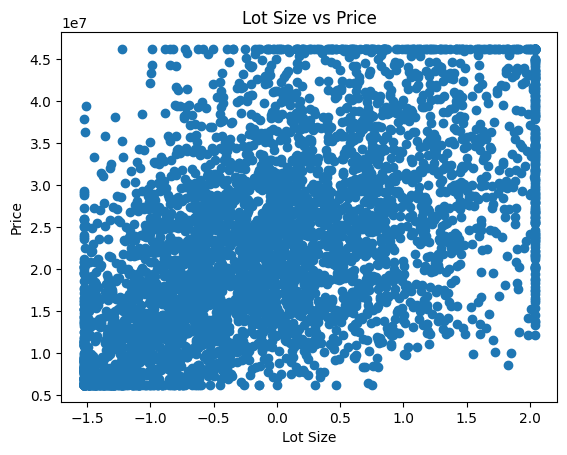

In [35]:
plt.scatter(new_final_df["lot_size_sqft"], new_final_df["house_price_inr"])
plt.xlabel("Lot Size")
plt.ylabel("Price")
plt.title("Lot Size vs Price")
plt.show()

* **Lot Size vs Price:** A scatter plot demonstrating a positive correlation between lot size and house price, again revealing artificial data ceilings at the maximum values.

## 12.MULTIVARIATE ANALYSIS

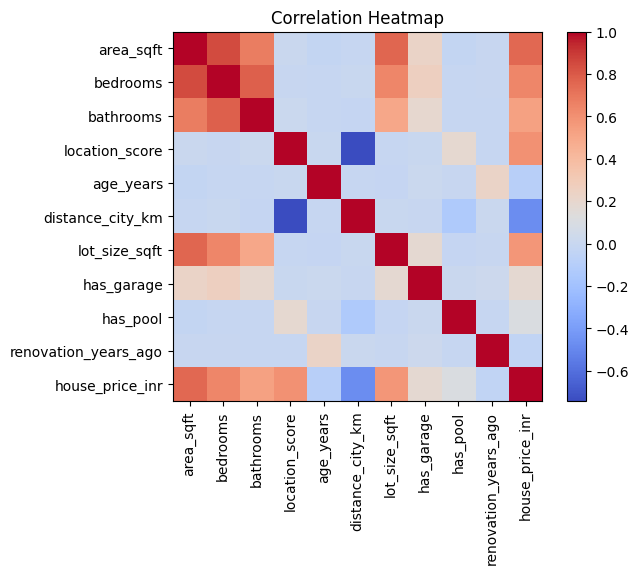

In [36]:
plt.imshow(new_final_df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(new_final_df.columns)), new_final_df.columns, rotation=90)
plt.yticks(range(len(new_final_df.columns)), new_final_df.columns)
plt.title("Correlation Heatmap")
plt.show()

* **Correlation Heatmap:** A color-coded matrix revealing the relationships between all numerical features, notably highlighting strong positive correlations between price and features like area, bedrooms, and lot size, alongside a strong negative correlation with distance from the city.

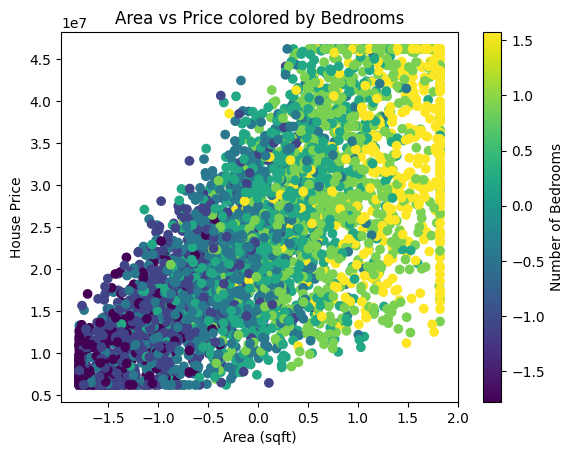

In [37]:
scatter = plt.scatter(
    new_final_df["area_sqft"],
    new_final_df["house_price_inr"],
    c=new_final_df["bedrooms"]
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")

plt.title("Area vs Price colored by Bedrooms")

plt.colorbar(scatter, label="Number of Bedrooms")

plt.show()

* **Area vs Price colored by Bedrooms:** A scatter plot indicating that within similar square footage, houses with a higher number of bedrooms typically command higher prices.

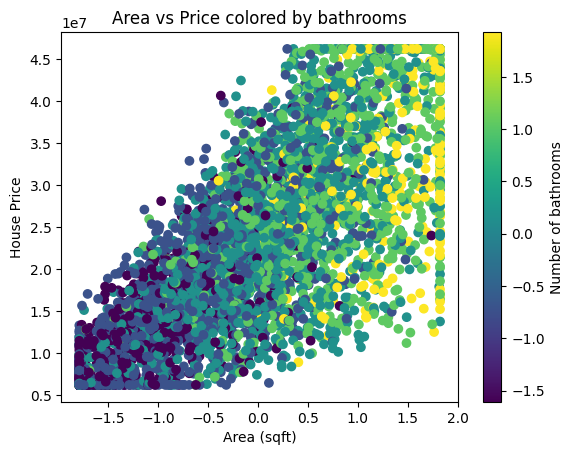

In [38]:
scatter = plt.scatter(
    new_final_df["area_sqft"],
    new_final_df["house_price_inr"],
    c=new_final_df["bathrooms"]
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")

plt.title("Area vs Price colored by bathrooms")

plt.colorbar(scatter, label="Number of bathrooms")

plt.show()

* **Area vs Price colored by Bathrooms:** A scatter plot demonstrating that houses with more bathrooms generally cluster toward higher price points for a given area.

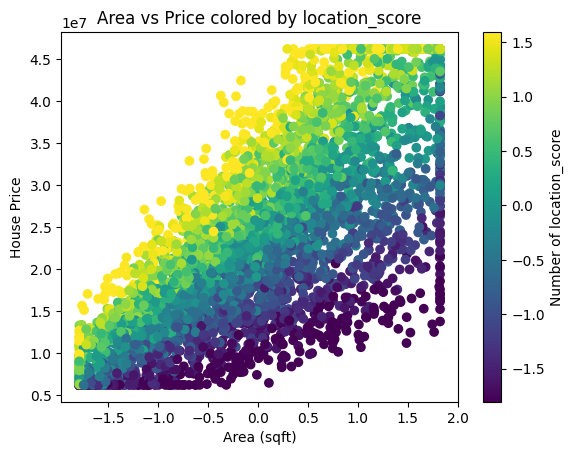

In [39]:
scatter = plt.scatter(
    new_final_df["area_sqft"],
    new_final_df["house_price_inr"],
    c=new_final_df["location_score"]
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")

plt.title("Area vs Price colored by location_score")

plt.colorbar(scatter, label="Number of location_score")

plt.show()

* **Area vs Price colored by location_score:** A clearly stratified scatter plot showing that a higher location score acts as a primary driver for higher house prices, creating distinct horizontal color bands.

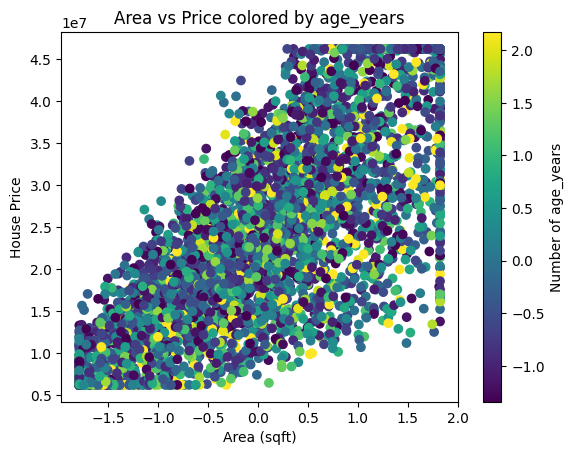

In [40]:
scatter = plt.scatter(
    new_final_df["area_sqft"],
    new_final_df["house_price_inr"],
    c=new_final_df["age_years"]
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")

plt.title("Area vs Price colored by age_years")

plt.colorbar(scatter, label="Number of age_years")

plt.show()

* **Area vs Price colored by age_years:** A scatter plot displaying a highly mixed color distribution, suggesting that house age has a much less consistent impact on price compared to location or area.

## Conclusion for Data preprosssing(csv files)

The dataset is now strictly numeric, uniformly scaled, and free of anomalies. It is fully prepared for the modeling phase, and the standardized features will help the Multiple Linear Regression model achieve faster convergence and more reliable coefficient estimations.